In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

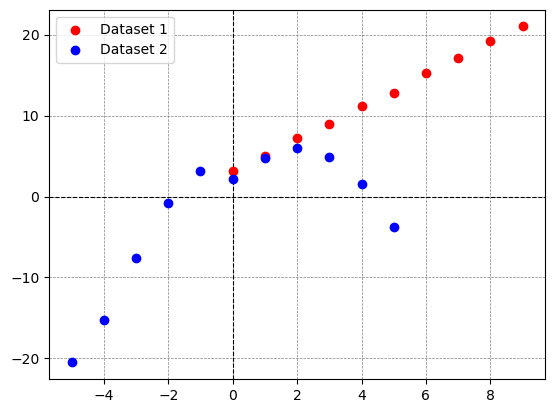

According to the graph, Dataset 1 is linear and Dataset 2 is a polynomial


In [27]:
#QUESTION 1

#Dataset 1 - gym hours vs muscle gain(X: hours in gym per week. Y: muscle mass gain (kg).)
X1=np.arange(0,9+1).reshape(-1,1)
Y1= np.array([3.1,5.0,7.2,8.9,11.2,12.8,15.2,17.1,19.2,21.0])

#Dataset 2 - load vs strength score (X: daily weightlifting load (kg). Y: muscle strength score.)
X2=np.arange(-5,5+1).reshape(-1,1)
Y2=np.array([-20.5,-15.2,-7.6,-0.8,3.2,2.1,4.7,6.0,4.9,1.6,-3.8])

#Plot the data (scatter plot) for each dataset and decide visually what kind of pattern it shows
plt.scatter(X1,Y1, color='red', zorder=5,label='Dataset 1')
plt.scatter(X2,Y2,color='blue',zorder=5,label='Dataset 2')
plt.grid(color='grey',linestyle='--',linewidth=0.5)
plt.axhline(0, color='black', linewidth=0.8,linestyle='--' )
plt.axvline(0, color='black', linewidth=0.8, linestyle="--")
plt.legend()
plt.show()
print('According to the graph, Dataset 1 is linear and Dataset 2 is a polynomial')


In [42]:
#QUESTION 2
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

#FIT LinearRegression on Dataset 1
model1= LinearRegression()
model1.fit(X1,Y1)
y1_pred = model1.predict(X1)
#FIT Polynomial Regression  on Dataset 2
feature_engine = PolynomialFeatures(degree=2, include_bias=True)
X_poly = feature_engine.fit_transform(X2)

model2= LinearRegression()
model2.fit(X_poly,Y2)
y2_pred = model2.predict(X_poly)


In [43]:
#QUESTION 3
from sklearn.metrics import mean_squared_error, r2_score
#calculate and print MSE and R² for 1
mse_1=mean_squared_error(Y1,y1_pred)
r2_1=r2_score(Y1,y1_pred)
print('THE MSE FOR THE LINEAR MODEL IS:',mse_1)
print('THE R2 FOR THE LINEAR MODEL IS:',r2_1)
#calculate and print MSE and R² for 2
mse_2=mean_squared_error(Y2,y2_pred)
r2_2=r2_score(Y2,y2_pred)
print('-'*50)
print('THE MSE FOR THE POLIYNOMIAL MODEL IS:',mse_2)
print('THE R2 FOR THE POLIYNOMIAL MODEL IS:',r2_2)

THE MSE FOR THE LINEAR MODEL IS: 0.018024242424242307
THE R2 FOR THE LINEAR MODEL IS: 0.9994557585602966
--------------------------------------------------
THE MSE FOR THE POLIYNOMIAL MODEL IS: 1.3413019707565152
THE R2 FOR THE POLIYNOMIAL MODEL IS: 0.9807079862229945


In [44]:
#QUESTION 4
#For the polynomial regression model only, calculate and print Adjusted R² for degree=2, 5, 8, 10
#! pip install dmba
from dmba import adjusted_r2_score
adj_r2 = adjusted_r2_score(Y2, model2.predict(X_poly), model2)

print('adjusted R2 score for the poliynomial model  ', adj_r2)


adjusted R2 score for the poliynomial model   0.9724399803185636


In [49]:
# QUESTION 5
#Using model.predict, predict the value of 4.5 hours in the first model and 0.5 load-kg in the second model
Y_pred_1 =model1.predict([[4.5]])
print(Y_pred_1)

X2_new = feature_engine.fit_transform(np.array([[0.5]]))

#X2_new = feature_engine.transform(np.array([[0.5]]))
Y_pred_2=model2.predict(X2_new)
print(Y_pred_2)

[12.07]
[5.05477273]
